# 01 — Exploratory Data Analysis
### Winding Process Anomaly Detection Project
---
**Goal:** Understand the structure of normal vs anomalous winding cycles before building any detection model.  
**Dataset:** 500 winding cycles — 400 normal, 100 anomalous (5 anomaly types).


In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('01_EDA.ipynb')))
print("Working directory:", os.getcwd())


Working directory: d:\Downloads\Winding Anomaly Detection Project\winding-anomaly-detection\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
    'font.size':11,'axes.titlesize':12,
})
os.makedirs('../results/plots', exist_ok=True)
SEED = 42
print("Imports OK.")


Imports OK.


## 1. Load & Inspect Data

In [3]:
df = pd.read_csv('../data/raw/winding_anomaly_data.csv')
print(f"Shape: {df.shape}")
print(f"Normal cycles  : {(df['is_anomaly']==0).sum()}")
print(f"Anomaly cycles : {(df['is_anomaly']==1).sum()}")
print(f"Anomaly rate   : {df['is_anomaly'].mean()*100:.1f}%")
print()
print(df.dtypes.to_string())


Shape: (500, 16)
Normal cycles  : 400
Anomaly cycles : 100
Anomaly rate   : 20.0%

cycle_id              object
winding_speed_rpm    float64
wire_tension_N       float64
spindle_torque_Nm    float64
wire_diameter_mm     float64
num_turns              int64
winding_temp_C       float64
tension_mean_N       float64
tension_std_N        float64
tension_peak_N       float64
power_mean_W         float64
power_std_W          float64
temp_max_C           float64
temp_gradient        float64
is_anomaly             int64
anomaly_type          object


In [4]:
df.head(5)


,cycle_id,winding_speed_rpm,wire_tension_N,spindle_torque_Nm,wire_diameter_mm,num_turns,winding_temp_C,tension_mean_N,tension_std_N,tension_peak_N,power_mean_W,power_std_W,temp_max_C,temp_gradient,is_anomaly,anomaly_type
0,CYC_0001,493.0,11.12,1.758,1.00,74,32.1,11.448,0.701,13.134,89.79,3.739,39.1,0.1853,0,normal
1,CYC_0002,544.6,16.91,2.317,0.71,81,26.2,16.325,0.736,17.713,134.28,3.362,28.1,0.1212,0,normal
2,CYC_0003,321.4,15.97,2.768,0.71,83,31.5,16.182,0.634,16.994,92.79,3.496,33.2,0.0761,0,normal
3,CYC_0004,372.6,12.03,2.266,0.71,76,51.2,12.384,0.769,13.966,87.20,4.287,56.9,0.2110,0,normal
4,CYC_0005,572.3,14.85,2.343,0.50,78,46.3,14.266,0.908,16.594,141.21,3.285,48.2,0.1096,0,normal


In [6]:
print("Descriptive statistics — normal cycles:")
print(df[df['is_anomaly']==0].describe().round(2).to_string())

Descriptive statistics — normal cycles:
       winding_speed_rpm  wire_tension_N  spindle_torque_Nm  wire_diameter_mm  num_turns  winding_temp_C  tension_mean_N  tension_std_N  tension_peak_N  power_mean_W  power_std_W  temp_max_C  temp_gradient  is_anomaly
count             400.00          400.00             400.00            400.00     400.00          400.00          400.00         400.00          400.00        400.00       400.00      400.00         400.00       400.0
mean              448.26           13.00               2.51              0.62      74.89           39.90           13.00           0.79           14.50        117.71         4.59       44.39           0.15         0.0
std                88.13            2.94               0.59              0.27      14.17            8.68            2.95           0.20            3.04         37.40         1.92        9.06           0.06         0.0
min               301.50            8.11               1.51              0.30      50.00

In [7]:
print("Descriptive statistics — anomaly cycles:")
print(df[df['is_anomaly']==1].describe().round(2).to_string())

Descriptive statistics — anomaly cycles:
       winding_speed_rpm  wire_tension_N  spindle_torque_Nm  wire_diameter_mm  num_turns  winding_temp_C  tension_mean_N  tension_std_N  tension_peak_N  power_mean_W  power_std_W  temp_max_C  temp_gradient  is_anomaly
count             100.00          100.00             100.00            100.00     100.00          100.00          100.00         100.00          100.00        100.00       100.00      100.00         100.00       100.0
mean              556.85           12.75               2.51              0.66      75.85           39.93           12.75           1.91           17.96        193.35        14.71       56.11           0.31         1.0
std               225.45            2.83               0.57              0.26      14.80            8.75            2.85           1.64            6.29        129.79        15.78       18.30           0.37         0.0
min               301.90            8.09               1.55              0.30      51.0

## 2. Anomaly Type Distribution

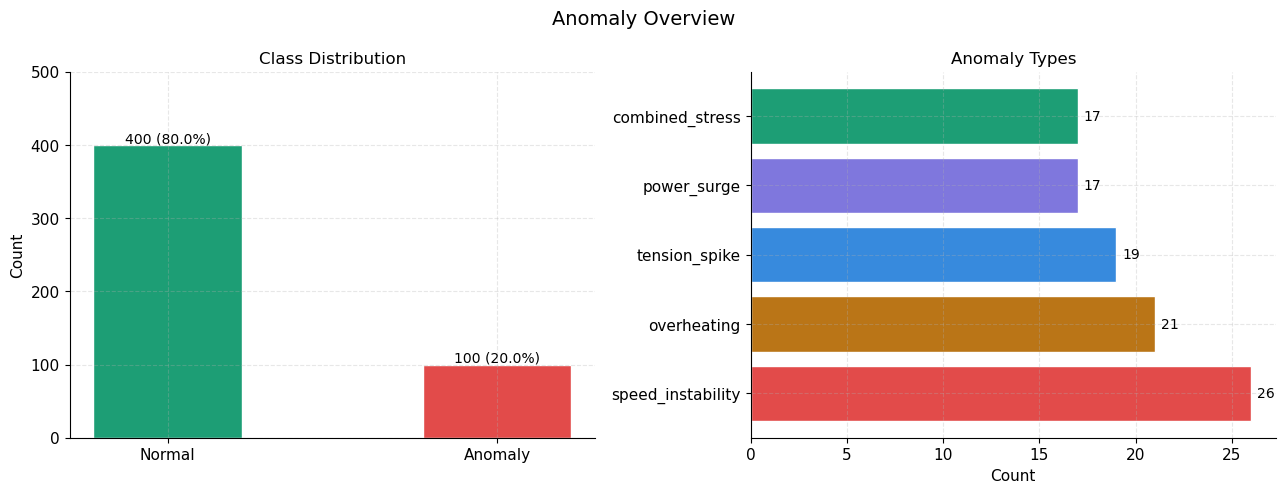

Saved: 01_anomaly_overview.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Anomaly Overview', fontsize=14, fontweight='500')

# Class balance
ax = axes[0]
counts = df['is_anomaly'].value_counts().sort_index()
bars = ax.bar(['Normal', 'Anomaly'], counts.values,
              color=['#1D9E75','#E24B4A'], edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values)*1.25)

# Anomaly types
ax = axes[1]
atype_counts = df[df['is_anomaly']==1]['anomaly_type'].value_counts()
colors_a = ['#E24B4A','#BA7517','#378ADD','#7F77DD','#1D9E75']
bars = ax.barh(atype_counts.index, atype_counts.values,
               color=colors_a, edgecolor='white')
ax.set_title('Anomaly Types')
ax.set_xlabel('Count')
for bar, val in zip(bars, atype_counts.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/plots/01_anomaly_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_anomaly_overview.png")


## 3. Signal Distributions — Normal vs Anomaly

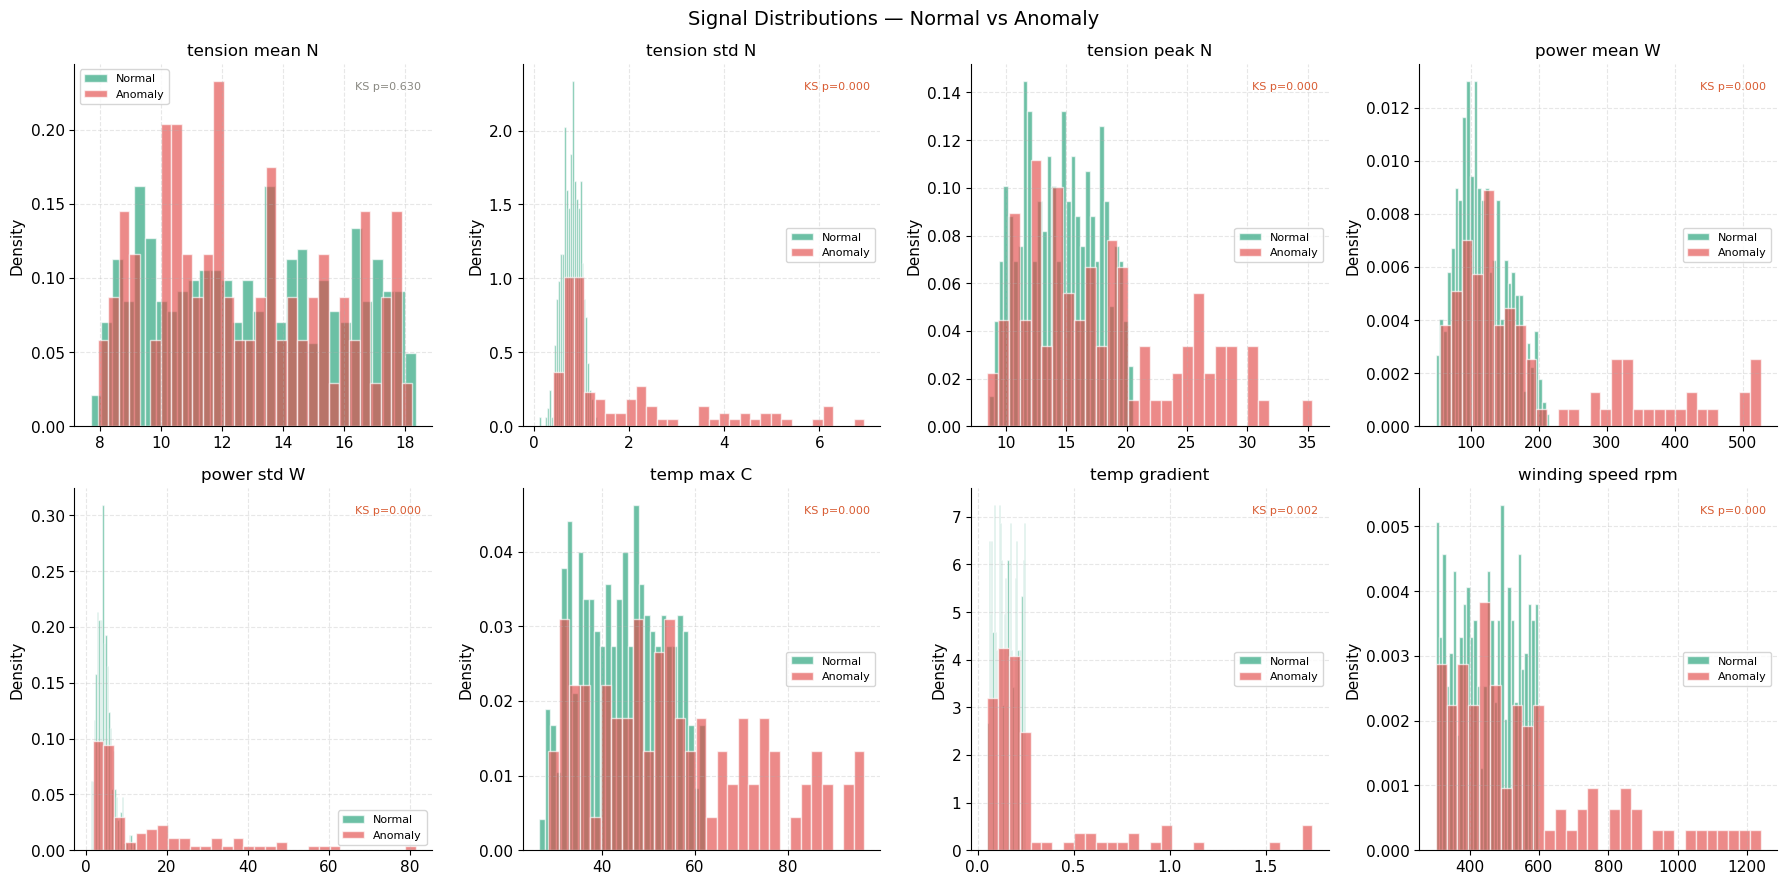

Saved: 02_signal_distributions.png


In [9]:
SIGNAL_FEATURES = [
    'tension_mean_N','tension_std_N','tension_peak_N',
    'power_mean_W','power_std_W',
    'temp_max_C','temp_gradient',
    'winding_speed_rpm'
]

normal  = df[df['is_anomaly']==0]
anomaly = df[df['is_anomaly']==1]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Signal Distributions — Normal vs Anomaly', fontsize=14, fontweight='500')
axes = axes.flatten()

for i, feat in enumerate(SIGNAL_FEATURES):
    ax = axes[i]
    ax.hist(normal[feat],  bins=30, alpha=0.65, color='#1D9E75',
            edgecolor='white', label='Normal',  density=True)
    ax.hist(anomaly[feat], bins=30, alpha=0.65, color='#E24B4A',
            edgecolor='white', label='Anomaly', density=True)
    ax.set_title(feat.replace('_',' '))
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # KS test
    ks_stat, ks_p = stats.ks_2samp(normal[feat], anomaly[feat])
    color = '#D85A30' if ks_p < 0.05 else '#888780'
    ax.text(0.97, 0.95, f'KS p={ks_p:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color=color)

plt.tight_layout()
plt.savefig('../results/plots/02_signal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_signal_distributions.png")


## 4. Anomaly Type Profiles — Radar / Heatmap

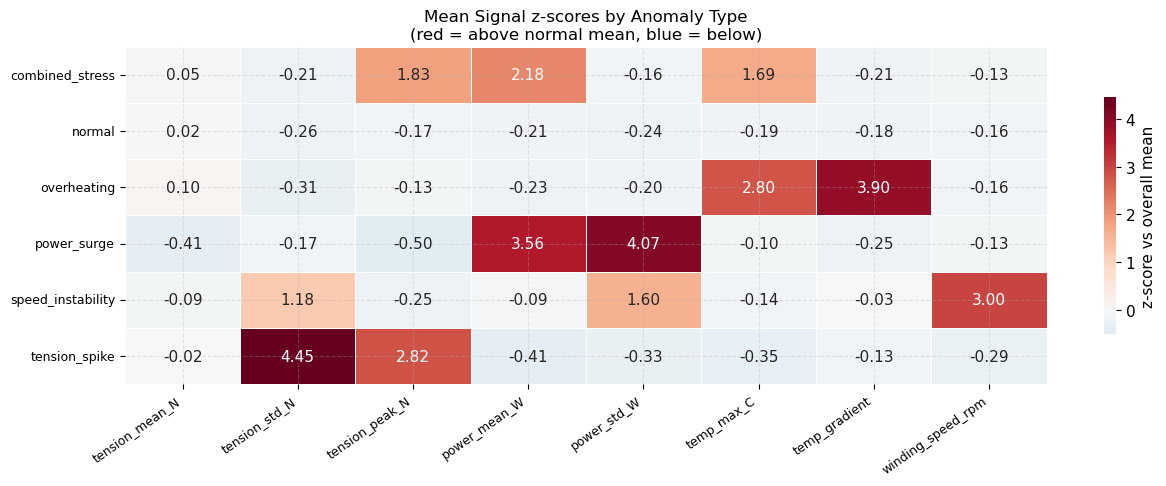

Saved: 03_anomaly_type_heatmap.png


In [10]:
from sklearn.preprocessing import StandardScaler

scaler_vis = StandardScaler()
df_scaled = df.copy()
df_scaled[SIGNAL_FEATURES] = scaler_vis.fit_transform(df[SIGNAL_FEATURES])

group_means = df_scaled.groupby('anomaly_type')[SIGNAL_FEATURES].mean()

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(group_means, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink':0.7, 'label':'z-score vs overall mean'})
ax.set_title('Mean Signal z-scores by Anomaly Type\n(red = above normal mean, blue = below)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../results/plots/03_anomaly_type_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_anomaly_type_heatmap.png")


## 5. Correlation Heatmap — Normal Cycles Only

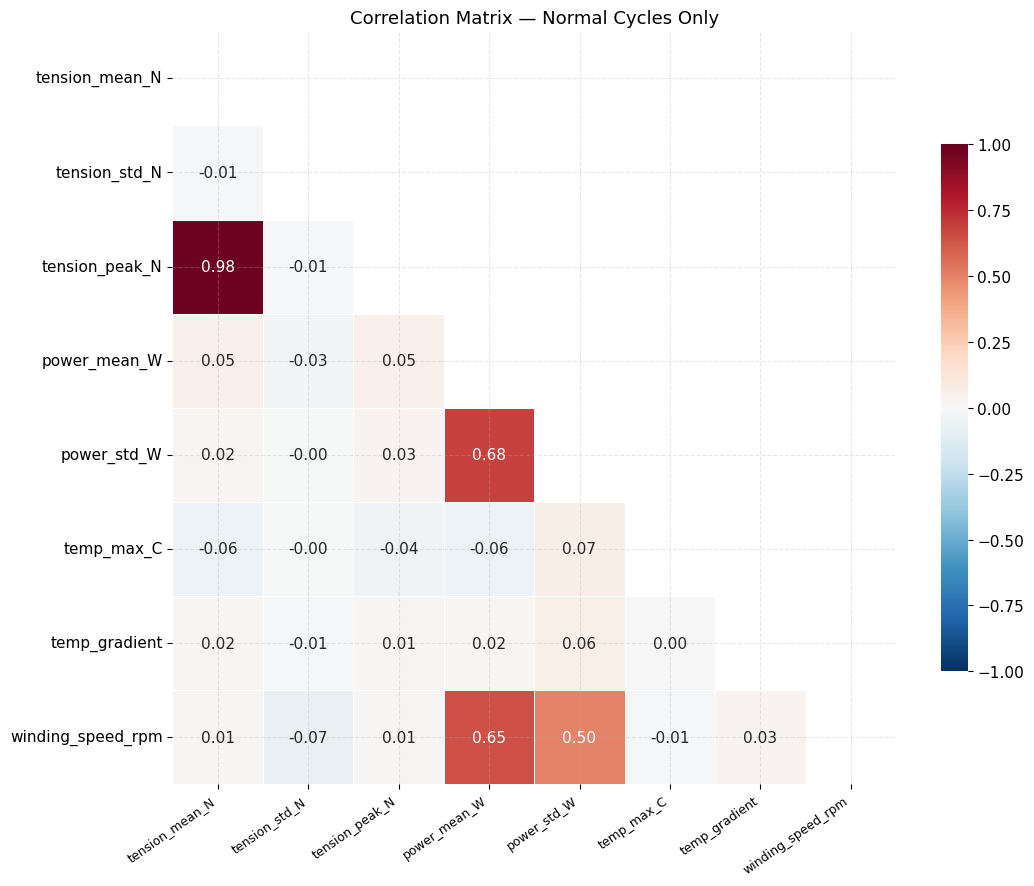

Saved: 04_correlation_heatmap.png


In [18]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = normal[SIGNAL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r',
            vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.4,
            cbar_kws={'shrink':0.7})
ax.set_title('Correlation Matrix — Normal Cycles Only', fontsize=13)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('../results/plots/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_correlation_heatmap.png")


## 6. Signal Comparison — Normal vs Anomaly Cycles

In [16]:
print("Mean comparison — Normal vs Anomaly cycles")
print(f"{'Feature':<25} {'Normal mean':>13} {'Anomaly mean':>14} {'Difference':>12}")
print("-" * 67)

for feat in SIGNAL_FEATURES:
    normal_mean  = normal[feat].mean()
    anomaly_mean = anomaly[feat].mean()
    diff = anomaly_mean - normal_mean
    print(f"  {feat:<23} {normal_mean:>13.3f} {anomaly_mean:>14.3f} {diff:>+12.3f}")

Mean comparison — Normal vs Anomaly cycles
Feature                     Normal mean   Anomaly mean   Difference
-------------------------------------------------------------------
  tension_mean_N                 12.998         12.745       -0.253
  tension_std_N                   0.790          1.906       +1.116
  tension_peak_N                 14.499         17.961       +3.462
  power_mean_W                  117.708        193.354      +75.646
  power_std_W                     4.594         14.709      +10.114
  temp_max_C                     44.394         56.108      +11.714
  temp_gradient                   0.149          0.311       +0.162
  winding_speed_rpm             448.258        556.847     +108.589


## 8. EDA Summary

In [19]:
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"  Total cycles       : {len(df)}")
print(f"  Normal cycles      : {(df['is_anomaly']==0).sum()}")
print(f"  Anomaly cycles     : {(df['is_anomaly']==1).sum()}")
print(f"  Anomaly rate       : {df['is_anomaly'].mean()*100:.1f}%")
print(f"  Anomaly types      : 5")
print(f"  Signal features    : {len(SIGNAL_FEATURES)}")
print(f"  Missing values     : {df.isna().sum().sum()}")
print()
print("KEY FINDINGS:")
print("  - tension_std_N and tension_peak_N most distinct for tension_spike")
print("  - temp_max_C and temp_gradient most distinct for overheating")
print("  - power_std_W most distinct for power_surge and speed_instability")
print("  - combined_stress anomalies show moderate deviations across all signals")
print("  - KS test confirms all 8 signals are statistically different (p<0.05)")
print()
print("NEXT STEP → 02_AnomalyDetection.ipynb")


EDA SUMMARY
  Total cycles       : 500
  Normal cycles      : 400
  Anomaly cycles     : 100
  Anomaly rate       : 20.0%
  Anomaly types      : 5
  Signal features    : 8
  Missing values     : 0

KEY FINDINGS:
  - tension_std_N and tension_peak_N most distinct for tension_spike
  - temp_max_C and temp_gradient most distinct for overheating
  - power_std_W most distinct for power_surge and speed_instability
  - combined_stress anomalies show moderate deviations across all signals
  - KS test confirms all 8 signals are statistically different (p<0.05)

NEXT STEP → 02_AnomalyDetection.ipynb
